In [1]:
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation

In [2]:
from PIL import Image

In [3]:
import torch

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
### 模型和预处理器

# 加载一个预训练的 图像预处理器 Feature Extractor，用于将原始图像转换为模型可以理解的格式
feature_extractor = SegformerFeatureExtractor.from_pretrained('nvidia/segformer-b0-finetuned-cityscapes-1024-1024')
# "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
# segformer-b0：SegFormer 的最小版本（参数最少）
# finetuned-cityscapes：在 Cityscapes 数据集上微调过
# 1024-1024：训练时使用的图像大小（你输入的图像会自动 resize 到这个尺寸）

# 加载一个已经 在 Cityscapes 数据集上训练好的 SegFormer 语义分割模型（B0 版本，轻量级），输出每个像素的类别预测
model = SegformerForSemanticSegmentation.from_pretrained('nvidia/segformer-b0-finetuned-cityscapes-1024-1024')
# SegformerForSemanticSegmentation专门用于语义分割任务。它封装了 SegFormer 模型的结构和相关的操作，使得用户可以方便地进行语义分割任务

'(ProtocolError('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer')), '(Request ID: 2e63ea67-b3af-43bd-8e6d-602d3231d298)')' thrown while requesting HEAD https://huggingface.co/nvidia/segformer-b0-finetuned-cityscapes-1024-1024/resolve/main/preprocessor_config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer')), '(Request ID: 7ac5ee61-480b-44c6-8f50-7e64d8d40c94)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/nvidia/segformer-b0-finetuned-cityscapes-1024-1024/21b3847fae21ddee674abd31129307b6a1235bd9/preprocessor_config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer')), '(Request ID: 91ee6e8a-eee1-41e8-8ec4-d9fce76467f1)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/nvidia/segformer-b0-finetuned-cityscapes-1024-1024/21b3847fae21ddee674abd31129307b6a1

In [7]:
# 加载街景图像
image = Image.open('5185d539fdc9f03fd5001492.jpg').convert('RGB')
inputs = feature_extractor(images = image,return_tensors = 'pt')

# PyTorch 格式的张量（tensor）就是 PyTorch 用来表示 多维数组（类似于 NumPy 中的 ndarray）的基本数据结构，是深度学习中模型训练和推理的核心“数据容器” -》 相当于神经网络专用的多维数组 。
# tensor是专门针对图像分析的一种数据结构
# 数字就是 0D tensor, array 就是 1D tensor, 二维矩阵就是 2D tensor…
# 在语义分割中，图像被表示为：[1, 3, 1024, 1024] : 一张图片， 通道数为3， 图像高宽1024 * 1024
# batch = 1,channel = 3,h = 1024,w = 1024

# feature_extractor 是 SegformerFeatureExtractor 的实例，它知道模型需要什么样的输入格式。
# 它负责的预处理包括：
# 缩放图像（比如 resize 到 1024×1024）
# 归一化像素值（如将 RGB 转为 [0,1] 范围）
# 转为 tensor 并排列成 [batch_size, 3, height, width] 的形状

# return_tensors="pt"
# 告诉它：返回 PyTorch 格式的张量（tensor）
# "pt"  PyTorch（如果你用 TensorFlow 就是 "tf"）

In [8]:
# 训练
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits # shape:[1,num_classes,H,W]
    segmentation = logits.argmax(dim = 1)[0].numpy()
segmentation

# with torch.no_grad(): 关闭 PyTorch 的自动梯度计算。为什么这么做？
# - 推理（inference）不需要梯度
# - 节省内存和计算资源
# - 加快速度
# - 在部署模型或可视化结果时，一般都用这个。
# - 如果是训练,那就要保留梯度计算

# outputs = model(**inputs)调用模型：将预处理后的图像数据输入模型，得到输出结果。

# logits 是模型预测的原始输出，代表每个像素属于每个类别的“未归一化得分”。它的维度含义如下：
# 1: batch size（只输入了一张图像）
# num_classes: 分割的类别数量（例如 Cityscapes 有 19 类）
# H, W: 输出的高和宽（通常是 1024x1024）

# argmax(dim=1): 对于每一个像素，选得分最高的类别索引作为最终预测。
# dim=1 表示在类别这个维度上取最大值
# [0]: 因为 batch size 是 1，只取这一张图的结果
# .numpy(): 将结果从 PyTorch 的 Tensor 转为 NumPy 数组，方便后续可视化或处理。

array([[ 8,  8,  8, ..., 10, 10, 10],
       [ 8,  8,  8, ..., 10, 10, 10],
       [ 8,  8,  8, ..., 10, 10, 10],
       ...,
       [13,  0, 13, ..., 13, 13, 13],
       [ 0,  0,  0, ..., 13, 13, 13],
       [ 0,  0,  0, ..., 13, 13, 13]])

with torch.no_grad() 是一个上下文管理器，它会在进入 with 语句块时临时关闭梯度计算功能，在执行完语句块内的代码后，再将梯度计算状态恢复到之前的状态。以下是其在模型推理代码中的使用示例

logits = outputs.logits # shape:[1,num_classes,H,W]：从模型输出 outputs 中提取 logits，logits 是模型最后一层的原始输出，通常是未经过激活函数处理的得分，其形状为 [1, num_classes, H, W]，其中 1 表示批量大小为 1，num_classes 是类别数量，H 和 W 分别是图像的高度和宽度。

segmentation = logits.argmax(dim = 1)[0].numpy()：
- logits.argmax(dim = 1)：在维度 1（即 num_classes 维度）上找到最大值的索引。对于每个像素位置 (i, j)，会从 num_classes 个得分中选择得分最高的类别作为该像素的预测类别。这个操作的结果是一个形状为 [1, H, W] 的张量，其中每个元素表示对应像素的预测类别标签。
- [0]：从批量中选择第一个样本的分割结果。因此，经过这一步操作后，得到的是一个形状为 [H, W] 的张量，表示单个图像的分割结果。
- .numpy()：将 PyTorch 张量转换为 NumPy 数组，方便后续处理或可视化。

segmentation：这一行代码本身不执行实际操作，只是引用前面计算得到的 segmentation 变量。

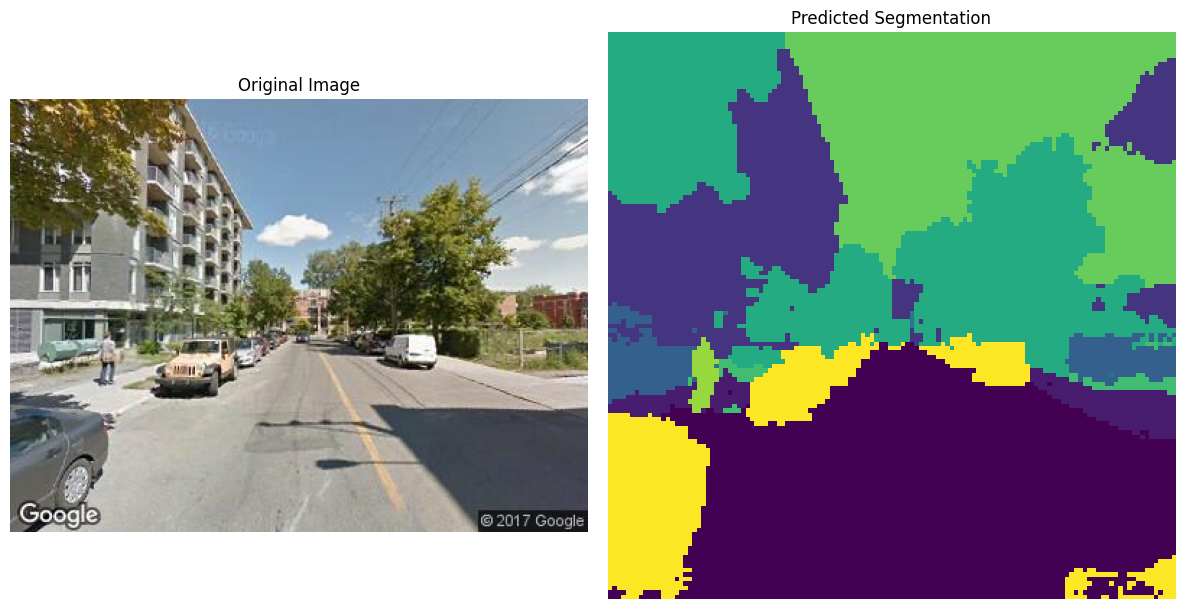

In [9]:
### 可视化
fig,axes = plt.subplots(1,2,figsize = (12,6))

# 加载原图
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

# 加载语义分割推理后的图像
axes[1].imshow(segmentation)
axes[1].set_title('Predicted Segmentation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

In [11]:
# 计算每一部分所占比例

In [12]:
# cityscapes 19种标签
cityscapes_labels = ["road", "sidewalk", "building", "wall", "fence", "pole", "traffic light", "traffic sign",
    "vegetation", "terrain", "sky", "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle"]

# 计算每个类别的像素数
unique,counts = np.unique(segmentation,return_counts = True)
total_pixels = segmentation.size

# 构建DataFrame
seg_df = pd.DataFrame({
    'label_id':unique,
    'label_name':[cityscapes_labels[i] for i in unique],
    'pixel_count':counts,
    'area_percent':counts/total_pixels*100
})

# 按面积排序
seg_df = seg_df.sort_values(by = 'area_percent',ascending = False).reset_index(drop = True)

seg_df

,label_id,label_name,pixel_count,area_percent
0,0,road,4872,29.736328
1,8,vegetation,3617,22.076416
2,10,sky,3178,19.396973
3,2,building,2272,13.867188
4,13,car,1394,8.508301
5,4,fence,482,2.941895
6,1,sidewalk,388,2.368164
7,9,terrain,102,0.622559
8,11,person,72,0.439453
9,5,pole,7,0.042725


In [13]:
# imshow有内置的cmap,我们可以自己定义color_mask
import numpy as np
import matplotlib.pyplot as plt

# cityscapes 标签颜色(19类)
CITYSCAPES_COLORS = {
    0:  (128, 64, 128),    # road
    1:  (244, 35, 232),    # sidewalk
    2:  (70, 70, 70),      # building
    3:  (102, 102, 156),   # wall
    4:  (190, 153, 153),   # fence
    5:  (153, 153, 153),   # pole
    6:  (250, 170, 30),    # traffic light
    7:  (220, 220, 0),     # traffic sign
    8:  (107, 142, 35),    # vegetation
    9:  (152, 251, 152),   # terrain
    10: (70, 130, 180),    # sky
    11: (220, 20, 60),     # person
    12: (255, 0, 0),       # rider
    13: (0, 0, 142),       # car
    14: (0, 0, 70),        # truck
    15: (0, 60, 100),      # bus
    16: (0, 80, 100),      # train
    17: (0, 0, 230),       # motorcycle
    18: (119, 11, 32),     # bicycle
}

# 将label mask转换为RGB彩图
def decode_segmentation_mask(segmentation):
    
    h,w = segmentation.shape
    color_mask = np.zeros((h,w,3),dtype = np.uint8) # 这个写法和前面的‘plt.imshow(np.ones((50,50,3),dtype = np.uint8)*color)’一样

    for label_id,color in CITYSCAPES_COLORS.items(): # 遍历字典键值对
        color_mask[segmentation == label_id] = color

    return color_mask
    

代码 color_mask[segmentation == label_id] = color 的作用是将 segmentation 数组中值等于 label_id 的所有像素位置，在 color_mask 数组中对应的像素设置为 color。

下面详细解释：

segmentation == label_id：这是一个布尔索引操作，会生成一个与 segmentation 数组形状相同的布尔数组。在这个布尔数组中，对应 segmentation 数组中值等于 label_id 的位置为 True，其余位置为 False。
color_mask[segmentation == label_id]：通过布尔数组对 color_mask 数组进行索引，选取 color_mask 中对应布尔数组为 True 的像素位置。
color_mask[segmentation == label_id] = color：将选取的这些像素位置的值设置为 color。由于 color_mask 是一个三维数组（形状为 (h, w, 3)），color 通常是一个长度为 3 的数组，表示 RGB 颜色值，所以会将对应位置的像素颜色设置为 color 所代表的颜色。

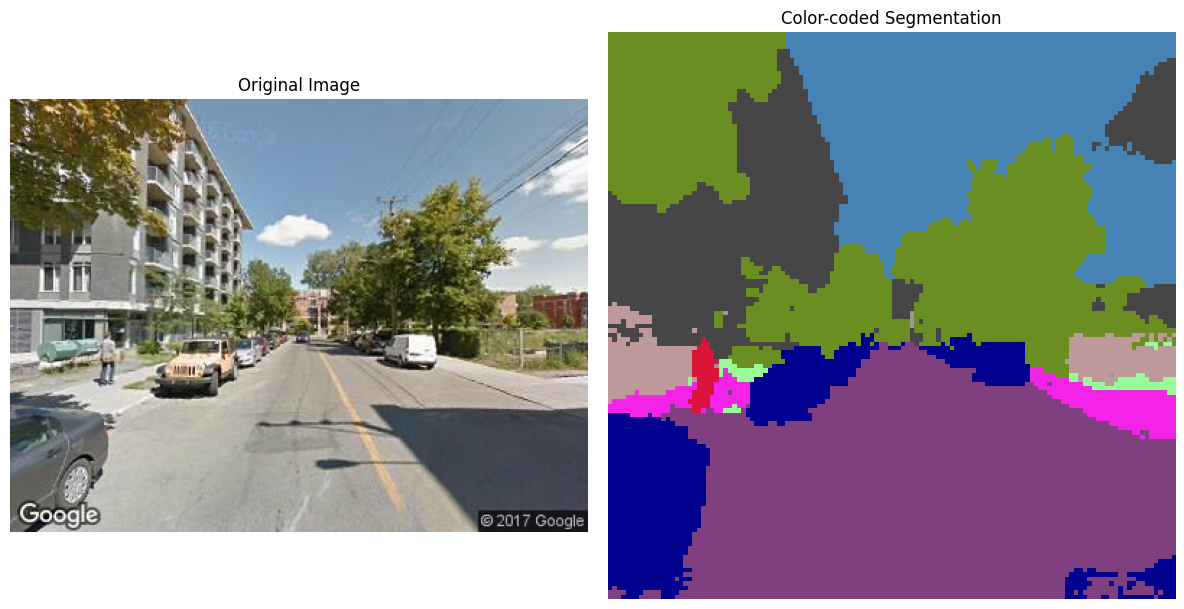

In [14]:
# 生成彩色 mask
color_mask = decode_segmentation_mask(segmentation)

# 显示原图 + 彩色分割图
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(color_mask)
axes[1].set_title("Color-coded Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
### 批量化语义分割

def GetStreetElements(img_path):

    image = Image.open(img_path).convert('RGB')
    inputs = feature_extractor(images = image,return_tensors = 'pt')

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits # [1,num_classes,H,W]
        segmentation = logits.argmax(dim = 1)[0].numpy()

    # 计算每个类别的像素数
    unique,counts = np.unique(segmentation,return_counts = True)
    total_pixel = segmentation.size

    # 构建 DataFrame
    seg_df = pd.DataFrame({
        'label_id':unique,
        'label_name':[cityscapes_labels[i] for i in unique],
        'pixel_count':counts,
        'area_percent':counts/total_pixel*100
    })

    return seg_df

In [16]:
data = pd.read_csv('imgs_data.csv')

In [17]:
data.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,cluster_centers_rgb,color_ratios_raw,cluster_centers_hsv,matched_colors_raw,matched_colors,color_ratios_matched,filename,...,red_ratio,orange_ratio,yellow_ratio,cyan_ratio,blue_ratio,purple_ratio,black_ratio,white_ratio,gray_ratio,color_number
0,0,0,0,[[153 160 165]\n [ 22 80 129]\n [127 123 111]...,[0.34035833 0.03794167 0.32735833 0.1571 0...,"[array([103, 19, 165], dtype=uint8), array([1...","['gray', 'cyan', 'orange', 'gray', 'yellow']","['gray', 'cyan', 'orange', 'yellow']","[np.float64(0.49745833333333334), np.float64(0...",51415142fdc9f04926007f43.jpg,...,0.0,0.327358,0.137242,0.037942,0.0,0.0,0.0,0.000000,0.497458,4
1,1,1,1,[[ 36 35 26]\n [171 174 177]\n [ 93 96 66]...,[0.27780833 0.1731 0.21171667 0.1403 0...,"[array([27, 71, 36], dtype=uint8), array([105,...","['yellow', 'gray', 'yellow', 'orange', 'yellow']","['yellow', 'gray', 'orange']","[np.float64(0.6866), np.float64(0.1731), np.fl...",50f5ed9afdc9f065f0008e32.jpg,...,0.0,0.140300,0.686600,0.000000,0.0,0.0,0.0,0.000000,0.173100,3
2,2,2,2,[[153 148 121]\n [ 53 54 32]\n [214 215 209]...,[0.202775 0.20121667 0.1415 0.24424167 0...,"[array([ 25, 53, 153], dtype=uint8), array([ ...","['yellow', 'yellow', 'white', 'cyan', 'yellow']","['yellow', 'white', 'cyan']","[np.float64(0.6142583333333334), np.float64(0....",513e6050fdc9f0358700b395.jpg,...,0.0,0.000000,0.614258,0.244242,0.0,0.0,0.0,0.141500,0.000000,3
3,3,3,3,[[ 68 72 69]\n [204 205 204]\n [157 159 158]...,[0.24099167 0.27510833 0.28238333 0.09298333 0...,"[array([68, 14, 72], dtype=uint8), array([ 60,...","['gray', 'white', 'gray', 'gray', 'yellow']","['gray', 'white', 'yellow']","[np.float64(0.6163583333333332), np.float64(0....",50f5eb28fdc9f065f0008096.jpg,...,0.0,0.000000,0.108533,0.000000,0.0,0.0,0.0,0.275108,0.616358,3
4,4,4,4,[[ 52 54 33]\n [143 140 133]\n [203 205 204]...,[0.23179167 0.2211 0.0928 0.12643333 0...,"[array([33, 99, 54], dtype=uint8), array([ 21,...","['yellow', 'gray', 'white', 'gray', 'gray']","['yellow', 'gray', 'white']","[np.float64(0.23179166666666667), np.float64(0...",50f5ec32fdc9f065f00087a7.jpg,...,0.0,0.000000,0.231792,0.000000,0.0,0.0,0.0,0.092800,0.675408,3


In [18]:
df_list = []
for filename in data['filename'].tolist():
    imagepath = f'/Users/zhaojunran/Documents/Python_Urban_Perception_and_Visual_Character/MIT_Place_Pulse_archive/gsv/final_photo_dataset/{filename}'
    seg_df = GetStreetElements(img_path = imagepath)
    seg_df['filename'] = filename
    df_list.append(seg_df)

In [19]:
df_list

[   label_id  label_name  pixel_count  area_percent  \
 0         0        road         4933     30.108643   
 1         1    sidewalk          581      3.546143   
 2         2    building         2310     14.099121   
 3         4       fence         1812     11.059570   
 4         8  vegetation         1358      8.288574   
 5        10         sky         5241     31.988525   
 6        13         car          149      0.909424   
 
                        filename  
 0  51415142fdc9f04926007f43.jpg  
 1  51415142fdc9f04926007f43.jpg  
 2  51415142fdc9f04926007f43.jpg  
 3  51415142fdc9f04926007f43.jpg  
 4  51415142fdc9f04926007f43.jpg  
 5  51415142fdc9f04926007f43.jpg  
 6  51415142fdc9f04926007f43.jpg  ,
    label_id  label_name  pixel_count  area_percent  \
 0         0        road         1861     11.358643   
 1         1    sidewalk            3      0.018311   
 2         2    building          190      1.159668   
 3         4       fence         1695     10.345459   
 4

In [20]:
results = []
for idx, df in enumerate(df_list):
    # 用 label_name 作为索引更方便取值
    df = df.set_index("label_name")
    filename = df['filename'].iloc[0] 
    
    # 提取需要的 area_percent，如果没有某一类就设为 0
    road = df.at["road", "area_percent"] if "road" in df.index else 0
    vegetation = df.at["vegetation", "area_percent"] if "vegetation" in df.index else 0
    building = df.at["building", "area_percent"] if "building" in df.index else 0

    results.append({
        "filename":  filename,  
        "road": road,
        "vegetation": vegetation,
        "building": building
    })

summary_df = pd.DataFrame(results)

In [21]:
summary_df

,filename,road,vegetation,building
0,51415142fdc9f04926007f43.jpg,30.108643,8.288574,14.099121
1,50f5ed9afdc9f065f0008e32.jpg,11.358643,49.255371,1.159668
2,513e6050fdc9f0358700b395.jpg,25.579834,27.362061,4.821777
3,50f5eb28fdc9f065f0008096.jpg,31.072998,9.954834,26.251221
4,50f5ec32fdc9f065f00087a7.jpg,24.835205,19.970703,19.769287
...,...,...,...,...
110642,5140db1bfdc9f04926003e88.jpg,15.924072,19.927979,7.598877
110643,513d9d13fdc9f03587007f59.jpg,34.967041,44.708252,12.976074
110644,513e6b92fdc9f0358700c04f.jpg,14.666748,9.649658,37.860107
110645,513d586efdc9f035870032f5.jpg,18.249512,14.367676,0.061035


In [22]:
data = data.merge(summary_df,on='filename')

In [23]:
data

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,cluster_centers_rgb,color_ratios_raw,cluster_centers_hsv,matched_colors_raw,matched_colors,color_ratios_matched,filename,...,cyan_ratio,blue_ratio,purple_ratio,black_ratio,white_ratio,gray_ratio,color_number,road,vegetation,building
0,0,0,0,[[153 160 165]\n [ 22 80 129]\n [127 123 111]...,[0.34035833 0.03794167 0.32735833 0.1571 0...,"[array([103, 19, 165], dtype=uint8), array([1...","['gray', 'cyan', 'orange', 'gray', 'yellow']","['gray', 'cyan', 'orange', 'yellow']","[np.float64(0.49745833333333334), np.float64(0...",51415142fdc9f04926007f43.jpg,...,0.037942,0.0,0.0,0.000000,0.000000,0.497458,4,30.108643,8.288574,14.099121
1,1,1,1,[[ 36 35 26]\n [171 174 177]\n [ 93 96 66]...,[0.27780833 0.1731 0.21171667 0.1403 0...,"[array([27, 71, 36], dtype=uint8), array([105,...","['yellow', 'gray', 'yellow', 'orange', 'yellow']","['yellow', 'gray', 'orange']","[np.float64(0.6866), np.float64(0.1731), np.fl...",50f5ed9afdc9f065f0008e32.jpg,...,0.000000,0.0,0.0,0.000000,0.000000,0.173100,3,11.358643,49.255371,1.159668
2,2,2,2,[[153 148 121]\n [ 53 54 32]\n [214 215 209]...,[0.202775 0.20121667 0.1415 0.24424167 0...,"[array([ 25, 53, 153], dtype=uint8), array([ ...","['yellow', 'yellow', 'white', 'cyan', 'yellow']","['yellow', 'white', 'cyan']","[np.float64(0.6142583333333334), np.float64(0....",513e6050fdc9f0358700b395.jpg,...,0.244242,0.0,0.0,0.000000,0.141500,0.000000,3,25.579834,27.362061,4.821777
3,3,3,3,[[ 68 72 69]\n [204 205 204]\n [157 159 158]...,[0.24099167 0.27510833 0.28238333 0.09298333 0...,"[array([68, 14, 72], dtype=uint8), array([ 60,...","['gray', 'white', 'gray', 'gray', 'yellow']","['gray', 'white', 'yellow']","[np.float64(0.6163583333333332), np.float64(0....",50f5eb28fdc9f065f0008096.jpg,...,0.000000,0.0,0.0,0.000000,0.275108,0.616358,3,31.072998,9.954834,26.251221
4,4,4,4,[[ 52 54 33]\n [143 140 133]\n [203 205 204]...,[0.23179167 0.2211 0.0928 0.12643333 0...,"[array([33, 99, 54], dtype=uint8), array([ 21,...","['yellow', 'gray', 'white', 'gray', 'gray']","['yellow', 'gray', 'white']","[np.float64(0.23179166666666667), np.float64(0...",50f5ec32fdc9f065f00087a7.jpg,...,0.000000,0.0,0.0,0.000000,0.092800,0.675408,3,24.835205,19.970703,19.769287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110642,110642,110642,110682,[[ 45 49 33]\n [244 246 247]\n [198 203 210]...,[0.2689 0.24570833 0.14939167 0.29500833 0...,"[array([38, 83, 49], dtype=uint8), array([100,...","['green', 'white', 'white', 'gray', 'gray']","['green', 'white', 'gray']","[np.float64(0.2689), np.float64(0.3951), np.fl...",5140db1bfdc9f04926003e88.jpg,...,0.000000,0.0,0.0,0.000000,0.395100,0.336000,3,15.924072,19.927979,7.598877
110643,110643,110643,110683,[[ 90 89 83]\n [160 161 161]\n [123 121 113]...,[0.25623333 0.12654167 0.29930833 0.18215833 0...,"[array([26, 20, 90], dtype=uint8), array([ 90,...","['gray', 'gray', 'gray', 'yellow', 'white']","['gray', 'yellow', 'white']","[np.float64(0.6820833333333334), np.float64(0....",513d9d13fdc9f03587007f59.jpg,...,0.000000,0.0,0.0,0.000000,0.135758,0.682083,3,34.967041,44.708252,12.976074
110644,110644,110644,110684,[[ 39 42 42]\n [222 218 211]\n [140 134 119]...,[0.231175 0.188975 0.22553333 0.229575 0...,"[array([90, 18, 42], dtype=uint8), array([ 19,...","['black', 'white', 'orange', 'cyan', 'gray']","['black', 'white', 'orange', 'cyan', 'gray']","[np.float64(0.231175), np.float64(0.188975), n...",513e6b92fdc9f0358700c04f.jpg,...,0.229575,0.0,0.0,0.231175,0.188975,0.124742,5,14.666748,9.649658,37.860107
110645,110645,110645,110685,[[229 232 236]\n [ 31 33 25]\n [133 128 119]...,[0.09069167 0.18770833 0.128825 0.15373333 0...,"[array([107, 8, 236], dtype=uint8), array([3...","['white', 'green', 'gray', 'yellow', 'white']","['white', 'green', 'gray', 'yellow']","[np.float64(0.5297333333333334), np.float64(0....",513d586efdc9f035870032f5.jpg,...,0.000000,0.0,0.0,0.000000,0.529733,0.128825,4,18.249512,14.367676,0.061035


In [24]:
data.to_csv('20251101.csv')